In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import emoji as emoji_lib
from wordcloud import WordCloud

In [2]:
train = pd.read_excel('case_1_labeled_data.xlsx')
test = pd.read_excel('case_1_text_to_predict.xlsx')

In [3]:
train.head(10)

,full_text,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM...,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik
5,@anakayahumi09 @irularr_ @ARSIPAJA Harus tetap...,Kualitas Pangan
6,🍱 Polsek Teluk Nibung monitoring Makan Bergizi...,Distribusi
7,eiw efisiensi tai nyusahin huwekk kemana duitn...,Anggaran
8,@kiharani Kesejahteraan petani naik karena MBG...,Ekonomi
9,@detikcom Ini lagi presiden main sandiwara.......,Sasaran Penerima


In [4]:
test.head()

,id,full_text
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ad...
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da..."
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas..."
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo


## Data Cleaning

## EDA

In [5]:
train['label'].value_counts()

label
Kualitas Pangan     1247
Politik              792
Anggaran             727
Lainnya              638
Tata Kelola          511
Sasaran Penerima     507
Distribusi           433
Ekonomi              145
Name: count, dtype: int64

#### Cek Duplikat

In [6]:
print(train.duplicated().sum())
print(train['full_text'].duplicated().sum())
print(test.duplicated().sum())

1
1
0


In [7]:
train = train.drop_duplicates()

print(train.duplicated().sum())

0


#### Panjang Token

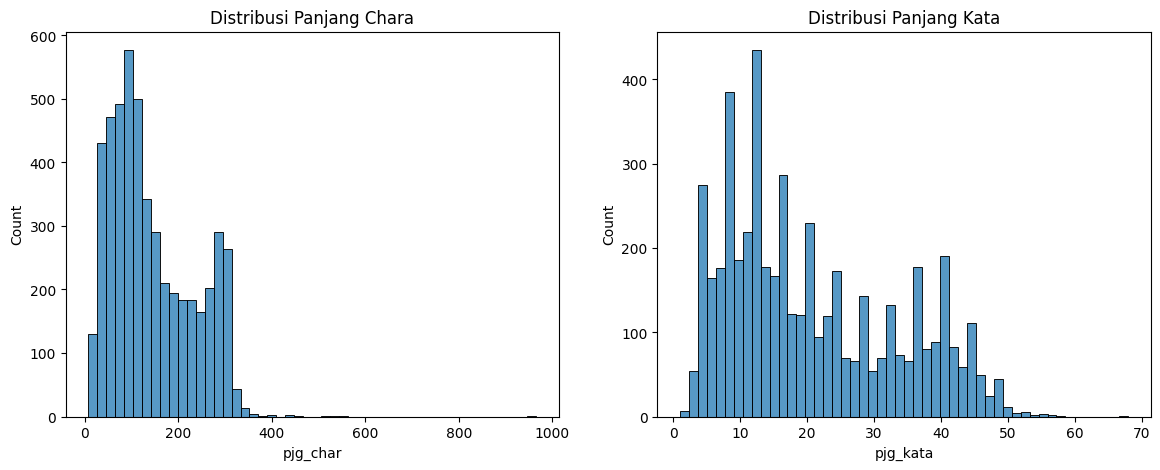

In [8]:
train['pjg_char'] = train['full_text'].apply(len)
train['pjg_kata'] = train['full_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(train['pjg_char'], bins=50, ax=axes[0])
axes[0].set_title("Distribusi Panjang Chara")


sns.histplot(train['pjg_kata'], bins=50, ax=axes[1])
axes[1].set_title("Distribusi Panjang Kata")

plt.show()

> Skew kanan banget, ini perlu key phrase(kata kunci) atau sesuatu yang bisa tambah representasinya

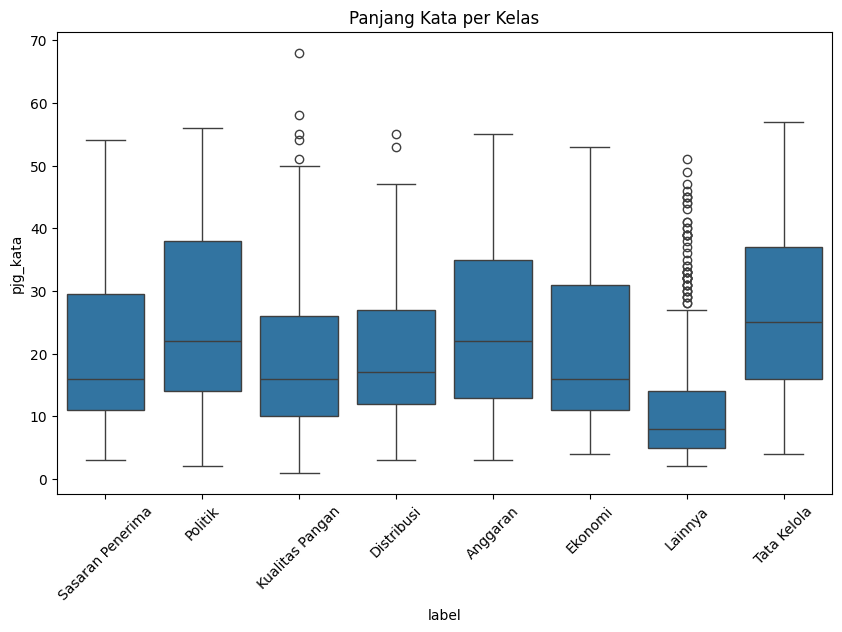

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(x='label', y='pjg_kata', data=train)
plt.xticks(rotation=45)
plt.title('Panjang Kata per Kelas')
plt.show()

> Dari rata-ratanya, semua label punya sedikit kata apakagi kelas "_lainnya_" paling sedikit sama kelas ini juga paling sedikit tweet jadi ada kemungkinan bakal ada model error dikelas yang ini.

#### Analisis N-Gram (Key Phrase)

> Berdasarkan pengalaman gen z, pasti ada key-phrase di Unigram, Bigram, sama Trigram seperti berikut:
- Unigram (kata tunggal): "anggaran", "gizi
- Bigram (2 kata): "salah sasaran"
- Trigram (3 kata): "makan bergizi gratis"

In [31]:
def cari_kata_berhadiah(teks, n, top_kata = 10):
    vec = CountVectorizer(
        ngram_range=(n,n),
        max_features=top_kata,
        stop_words=None, # kenapa gak hapus stopword? ya namanya masih nyoba
    )

    X= vec.fit_transform(teks)
    jumlah_kata = X.sum(axis=0)
    frekuensi_kata = [(kata, jumlah_kata[0, idx]) for kata, idx in vec.vocabulary_.items()]

    frekuensi_kata = sorted(frekuensi_kata, key=lambda x: x[1], reverse=True)
    return frekuensi_kata[:top_kata]

In [32]:
def plot_ngram_all_classes(data, n=2, top_kata=10):
    daftar_label = data['label'].unique()
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))  # 8 kelas, 2x4 grid
    axes = axes.flatten()

    for i, kelas in enumerate(daftar_label):
        teks = data[data['label'] == kelas]['full_text']
        hasil = cari_kata_berhadiah(teks, n, top_kata)
        data_plot = pd.DataFrame(hasil, columns=['N-gram', 'Frekuensi'])

        sns.barplot(data=data_plot, x='Frekuensi', y='N-gram',hue='N-gram',
                    ax=axes[i], palette='viridis')
        axes[i].set_title(kelas, fontsize=12)
        axes[i].set_ylabel('')

    plt.suptitle(f'Top {top_kata} {n}-gram untuk Setiap Kelas', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

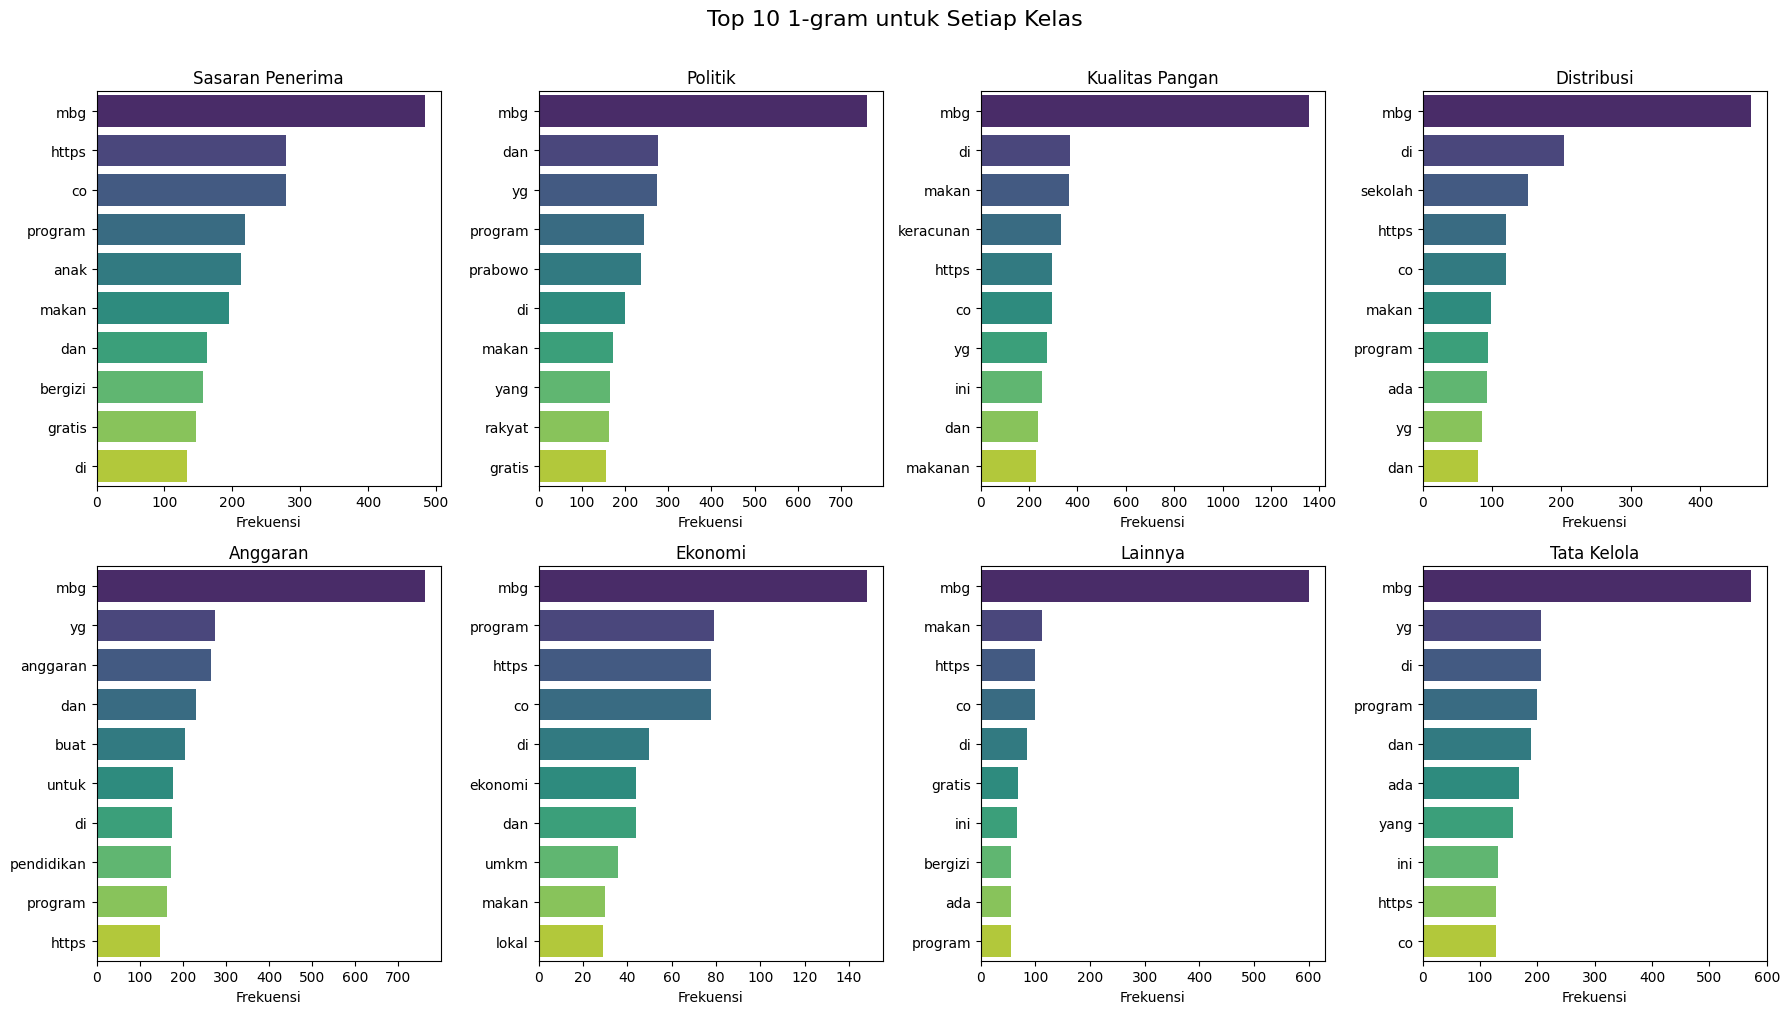

In [33]:
plot_ngram_all_classes(train, n=1, top_kata=10)   # unigram

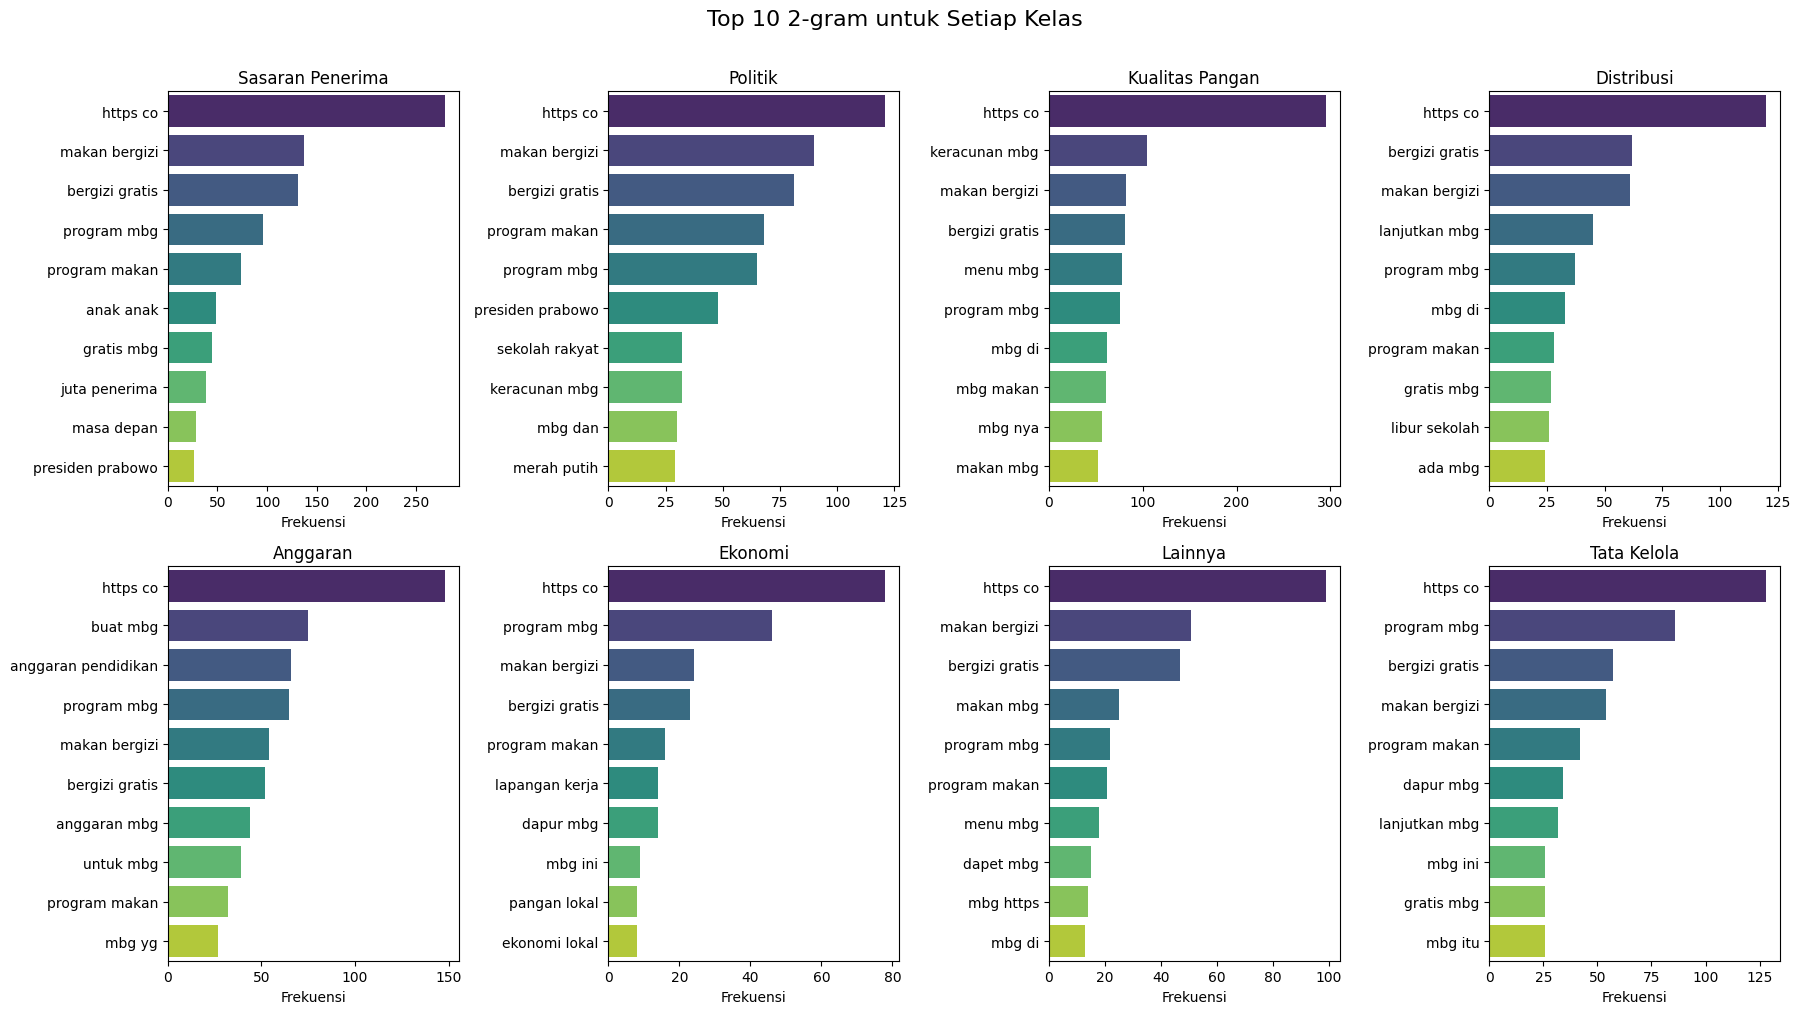

In [34]:
plot_ngram_all_classes(train, n=2, top_kata=10)   # bigram

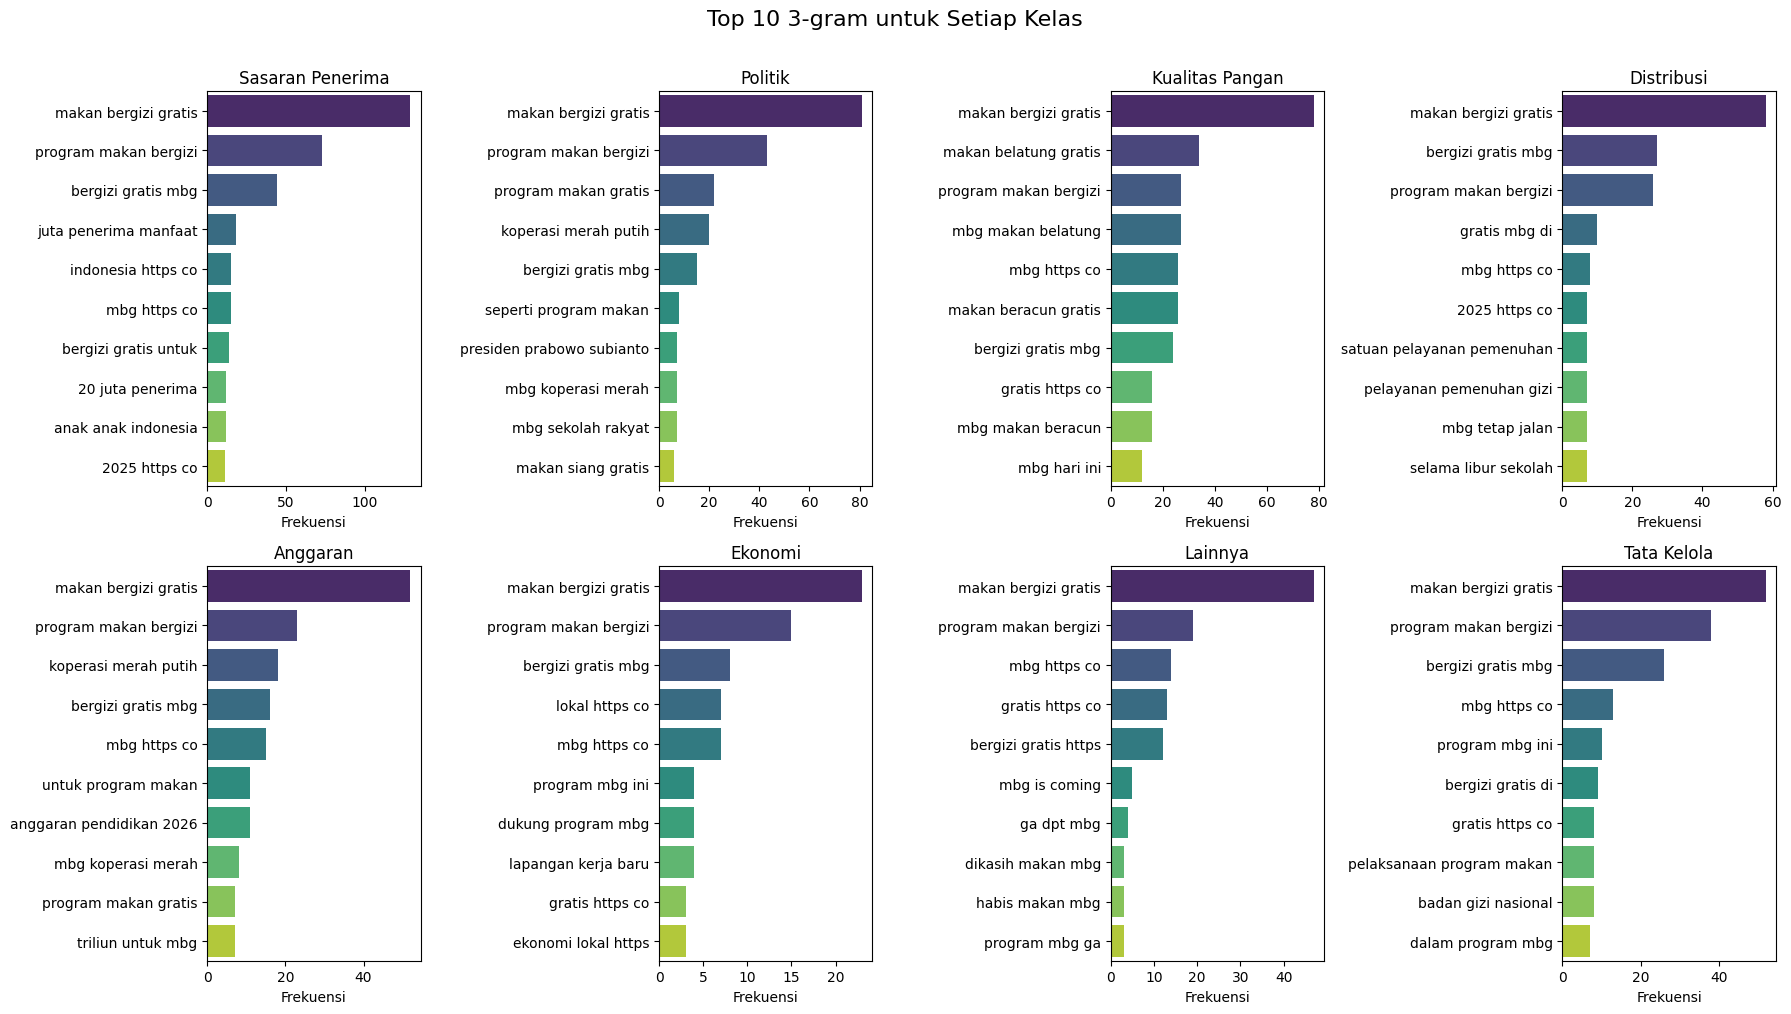

In [35]:
plot_ngram_all_classes(train, n=3, top_kata=10)   # trigram

> **Kayaknya lebih bagus kalo bersihin dulu terus pake tf-idf sih**


#### Analisis Emoji

In [15]:
def ekstrak_emoji(teks):    
    return [c for c in teks if c in emoji_lib.EMOJI_DATA]

In [16]:
train.iloc[6]

full_text    🍱 Polsek Teluk Nibung monitoring Makan Bergizi...
label                                               Distribusi
pjg_char                                                   229
pjg_kata                                                    33
Name: 6, dtype: object

In [17]:
for i in range(50):
    raw = train['full_text'].iloc[i]
    emojis = ekstrak_emoji(raw)
    if emojis:
        print(f"Tweet {i}: {emojis}")

Tweet 0: ['🥲']
Tweet 6: ['🍱', '👦', '👧']
Tweet 16: ['🙂']
Tweet 25: ['🥰']
Tweet 29: ['🤣', '🫵', '🏻']
Tweet 30: ['😋', '😋', '👌', '🔥']
Tweet 32: ['😅']
Tweet 40: ['🤓', '😔', '✊', '🖐', '😹', '🖐']
Tweet 45: ['😑']
Tweet 47: ['😭', '👊']
Tweet 49: ['😭']


In [18]:
def emoji_per_kelas(df, kelas, top=10, kolom='full_text'):
    teks_kelas = df[df['label'] == kelas][kolom]
    semua = []
    for t in teks_kelas:
        emoj_raw = ekstrak_emoji(t)
        # demojize supaya kebaca di plot
        emoj_text = [emoji_lib.demojize(e) for e in emoj_raw]
        semua.extend(emoj_text)
    counter = Counter(semua)
    return counter.most_common(top)

In [19]:
def plot_emoji_per_kelas(df, kelas, top=10, kolom='full_text'):
    hasil = emoji_per_kelas(df, kelas, top, kolom)
    if not hasil:
        print(f"Kelas '{kelas}' tidak memiliki emoji yang cukup.")
        return None
    df_plot = pd.DataFrame(hasil, columns=['Emoji', 'Frekuensi'])

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_plot, x='Frekuensi', y='Emoji',
                hue='Emoji', palette='viridis', legend=False)
    plt.title(f'Top {top} Emoji untuk kelas: {kelas}')
    plt.tight_layout()
    plt.show()
    return df_plot

In [20]:
def plot_emoji_semua(df, top=10, kolom='full_text'):
    daftar_label = df['label'].unique()
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for i, kelas in enumerate(daftar_label):
        hasil = emoji_per_kelas(df, kelas, top, kolom)
        if hasil:
            df_plot = pd.DataFrame(hasil, columns=['Emoji', 'Frekuensi'])
            sns.barplot(data=df_plot, x='Frekuensi', y='Emoji',
                        hue='Emoji', palette='viridis', legend=False, ax=axes[i])
            axes[i].set_title(kelas, fontsize=12)
        else:
            axes[i].text(0.5, 0.5, 'Tidak ada emoji', ha='center', va='center')
        axes[i].set_ylabel('')

    plt.suptitle(f'Top {top} Emoji per Kelas (dari Teks Asli)', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

In [21]:
def emoji_matrix(df, top_global=30, kolom='full_text'):
    daftar_label = df['label'].unique()

    counter_global = Counter()
    for t in df[kolom]:
        emoj_raw = ekstrak_emoji(t)
        emoj_text = [emoji_lib.demojize(e) for e in emoj_raw]
        counter_global.update(emoj_text)
    top_emoji = [e for e, _ in counter_global.most_common(top_global)]

    matriks = []
    for emo_teks in top_emoji:
        row = {'emoji': emo_teks}
        for kelas in daftar_label:
            teks_kelas = df[df['label'] == kelas][kolom]
            count = 0
            for t in teks_kelas:
                t_demojized = emoji_lib.demojize(t)
                if emo_teks in t_demojized:
                    count += 1
            row[kelas] = count
        matriks.append(row)

    return pd.DataFrame(matriks)

def plot_emoji_heatmap(df, top_global=30, kolom='full_text'):
    df_mat = emoji_matrix(df, top_global, kolom)
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_mat.set_index('emoji'), annot=True, cmap='YlGnBu')
    plt.title('Frekuensi Kemunculan Emoji per Kelas')
    plt.tight_layout()
    plt.show()
    return df_mat

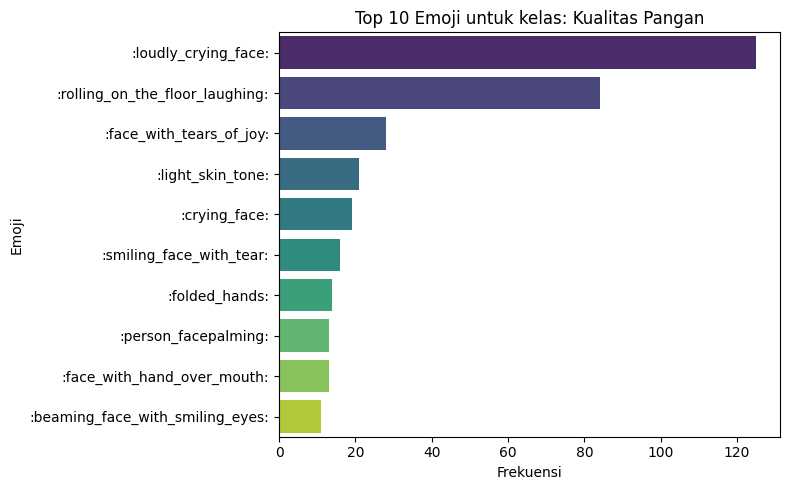

,Emoji,Frekuensi
0,:loudly_crying_face:,125
1,:rolling_on_the_floor_laughing:,84
2,:face_with_tears_of_joy:,28
3,:light_skin_tone:,21
4,:crying_face:,19
5,:smiling_face_with_tear:,16
6,:folded_hands:,14
7,:person_facepalming:,13
8,:face_with_hand_over_mouth:,13
9,:beaming_face_with_smiling_eyes:,11


In [22]:
plot_emoji_per_kelas(train, "Kualitas Pangan", top=10, kolom='full_text')

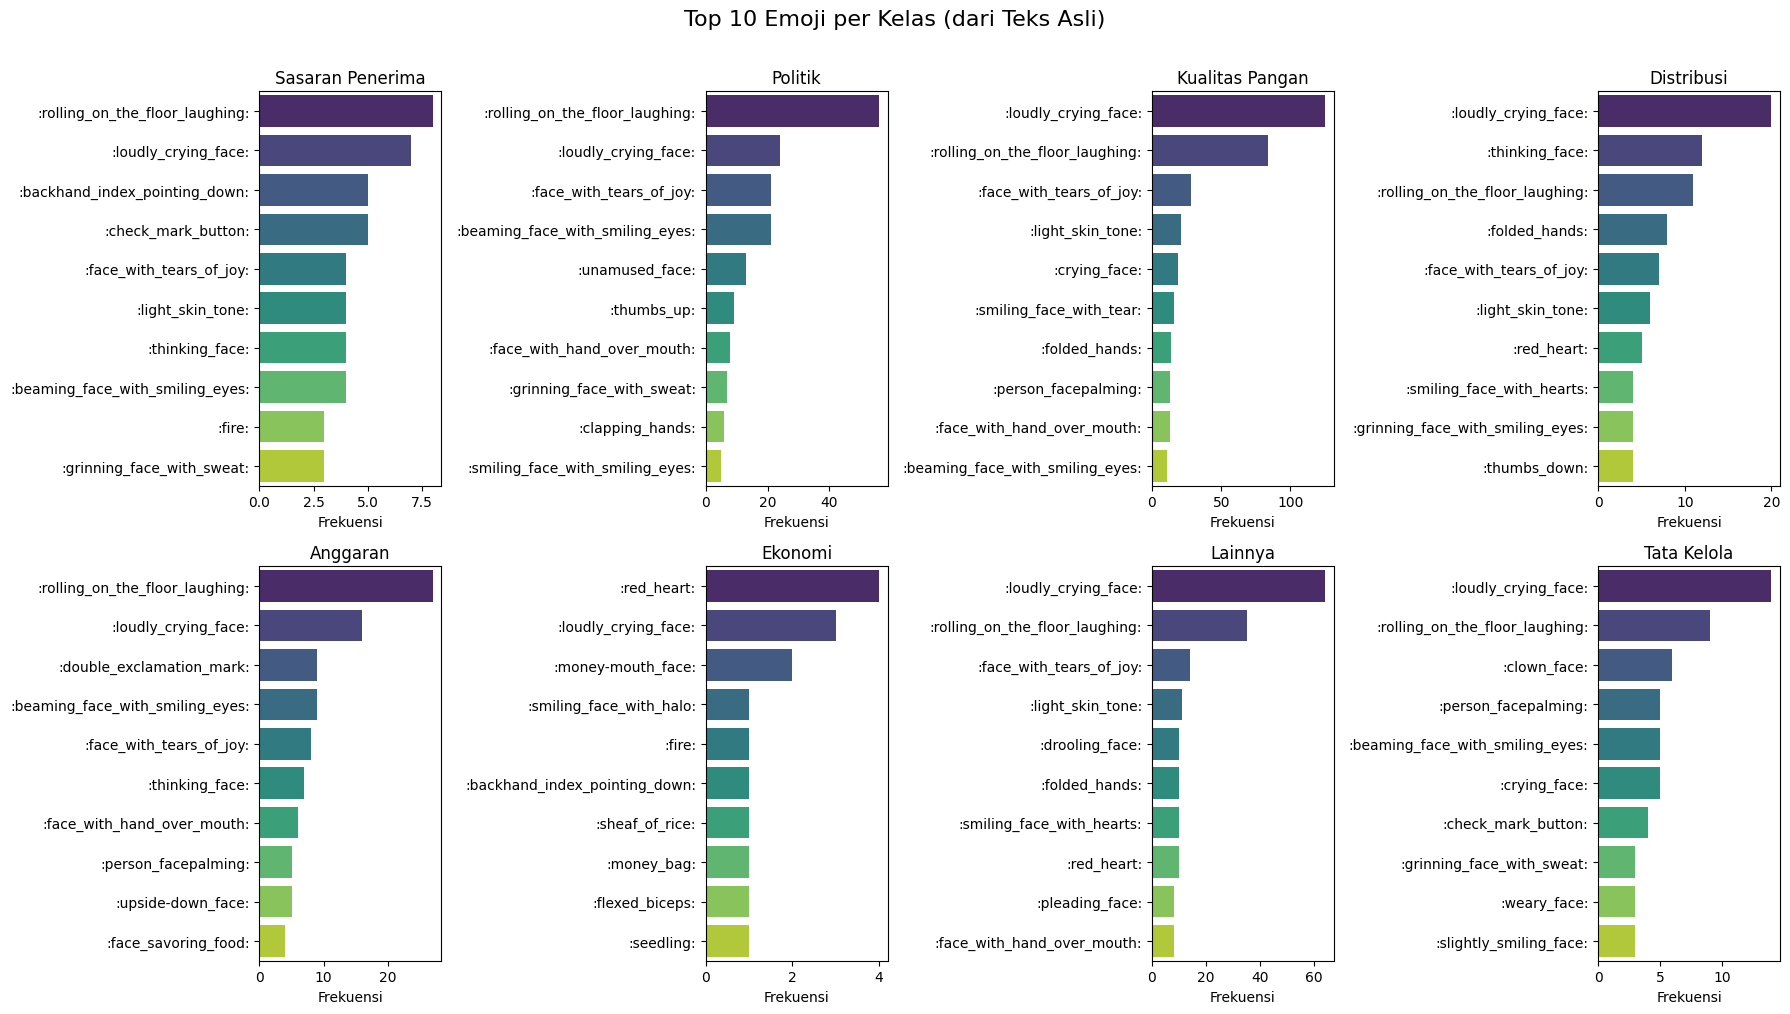

In [23]:
plot_emoji_semua(train, top=10, kolom='full_text')

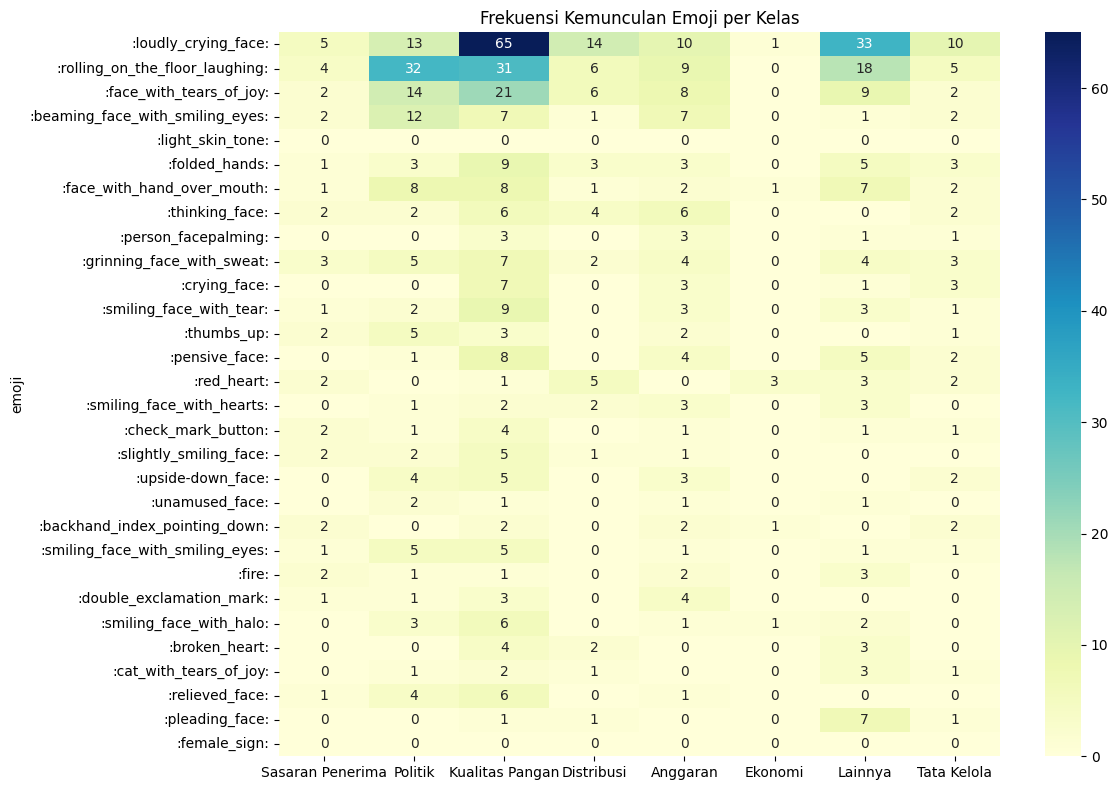

In [24]:
df_heat = plot_emoji_heatmap(train, top_global=30, kolom='full_text')

> Gak bisa jadi interpretasi prediksi kelas (model) sih ini, cuma bisa jadi analisis tweetnya (sentimen terhadap kelasnya)

#### Kemiripan Kelas (Class similarity)

> Kenapa ini mau dicoba? karena beberapa kelas mungkin bersinggungan banget alias deket banget lah. Contoh kayak anggaran sama ekonomi masih satu ranah lah ya

## Preprocessing